# Задание лабораторной работы 2
Реализуйте данный вид эквализации самостоятельно.

C:\Users\user\AppData\Local\Temp\ipykernel_16380\1205531632.py:44: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(gray_image1.reshape(-1), 256, (0, 256))
C:\Users\user\AppData\Local\Temp\ipykernel_16380\1205531632.py:47: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(result_image_2.reshape(-1), 256, (0, 256))
C:\Users\user\AppData\Local\Temp\ipykernel_16380\1205531632.py:50: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(cv_result_image.reshape(-1), 256, (0, 256))


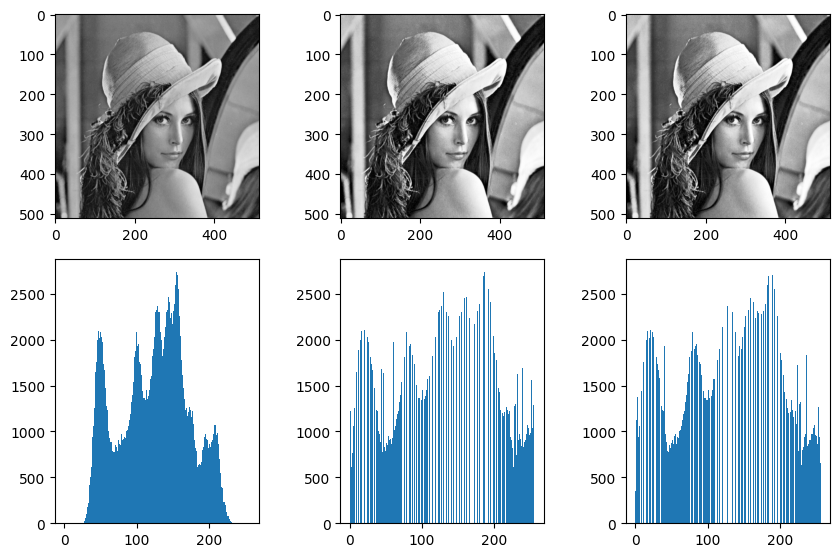

In [2]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

image1 = cv.imread('lenna.png')
gray_image1 = cv.cvtColor(image1, cv.COLOR_BGR2GRAY)

def lut_eq(img):
    res = np.array(np.unique(img, return_counts=True)).T
    histogram_sum = sum(res[:, 1])

    lut = np.zeros(256, dtype=np.float32)
    cumulativeSum = np.cumsum(res[:, 1])

    for i in range(res.shape[0]):
        val = int(res[i, 0])
        lut[val] = 255 * cumulativeSum[i] / histogram_sum

    copy = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            pixelValue = img[i, j]
            copy[i, j] = lut[pixelValue]

    return copy

result_image_2 = lut_eq(gray_image1)

cv_result_image = cv.equalizeHist(gray_image1)


plt.figure(figsize=(10, 7))

plt.subplot(231)
plt.imshow(gray_image1, cmap='gray')

plt.subplot(232)
plt.imshow(result_image_2, cmap='gray')

plt.subplot(233)
plt.imshow(cv_result_image, cmap='gray')

plt.subplot(234)
plt.hist(gray_image1.reshape(-1), 256, (0, 256))

plt.subplot(235)
plt.hist(result_image_2.reshape(-1), 256, (0, 256))

plt.subplot(236)
plt.hist(cv_result_image.reshape(-1), 256, (0, 256))

plt.subplots_adjust(wspace=0.4, hspace=0.04)

plt.show()